# Classification

<div dir='rtl'>
    <p>الـ <code>classification</code> هو نوع من انواع تعليم الاله ومهمة التصنيف او الاجابه بـ <code>True</code> او <code>False</code></p>
    <ul dir='ltr'>
        <li><b>True</b> = 1</li>
        <li><b>False</b> = 0</li>
    </ul>
    <p>لنقل مثلاً اننا نريد إنشاء <code>model</code> ليخبرنا اذا كانت هذه اللعبه ستنجح ام لا</p>
    <p>الشرط هو إذا كانت مبيعاتها فوق 1 مليون، إذاً فهى ناجحه</p>
    <p>سوف نستخدم <code>model</code> يسمى <code>LogisticRegression</code> وهو المسئول عن الـ <code>classification</code></p>
    <p></p>
</div>

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(
    "vgsales.csv",
    dtype={
        "NA_Sales": np.float32,
        "EU_Sales": np.float32,
        "JP_Sales": np.float32,
        "Other_Sales": np.float32,
        "Global_Sales": np.float32,
    }
)
df['Global_Sales'] = df[["NA_Sales","EU_Sales","JP_Sales", "Other_Sales"]].sum(axis=1).round(2)
df = df[["NA_Sales","EU_Sales","Global_Sales"]]
df.head(10)

,NA_Sales,EU_Sales,Global_Sales
0,41.490002,29.02,82.739998
1,29.080000,3.58,40.240002
2,15.850000,12.88,35.830002
3,15.750000,11.01,33.000000
4,11.270000,8.89,31.379999
5,23.200001,2.26,30.260000
6,11.380000,9.23,30.010000
7,14.030000,9.20,29.010000
8,14.590000,7.06,28.610001
9,26.930000,0.63,28.309999


## Prepare the data
<p dir='rtl'>إذا كانت المبيعات العالميه فوق مليون إذا كانت ناجحه <code>True</code> غير ذالك فهى فاشله <code>False</code></p>

In [3]:
df['Is_Success'] = np.where(df['Global_Sales'] >= 1, True, False)
df

,NA_Sales,EU_Sales,Global_Sales,Is_Success
0,41.490002,29.02,82.739998,True
1,29.080000,3.58,40.240002,True
2,15.850000,12.88,35.830002,True
3,15.750000,11.01,33.000000,True
4,11.270000,8.89,31.379999,True
...,...,...,...,...
16593,0.010000,0.00,0.010000,False
16594,0.010000,0.00,0.010000,False
16595,0.000000,0.00,0.000000,False
16596,0.000000,0.01,0.010000,False


In [4]:
X = df[["NA_Sales", "EU_Sales"]]
Y = df['Is_Success']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.07, random_state=42)

In [5]:
model = LogisticRegression()
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
f"Score: {model.score(x_test, y_test) * 100:.2f}"

'Score: 98.80'

In [7]:
prediction = model.predict(x_test)
dt = pd.DataFrame(
    {
        "NA_Sales": x_test['NA_Sales'].values,
        "EU_Sales": x_test['EU_Sales'].values,
        "Is_Success": y_test.values,
        "Prediction": prediction
    }
)
dt

,NA_Sales,EU_Sales,Is_Success,Prediction
0,0.01,0.11,False,False
1,0.32,0.04,False,False
2,0.00,0.02,False,False
3,0.01,0.01,False,False
4,0.20,0.11,False,False
...,...,...,...,...
1157,0.78,0.75,True,True
1158,0.16,0.09,False,False
1159,0.04,0.00,False,False
1160,0.25,0.28,False,False


In [8]:
print(f"Correct answers: {dt[dt['Is_Success'] == dt['Prediction']].shape[0]} ✅")
print(f"Wrong answers: {dt[dt['Is_Success'] != dt['Prediction']].shape[0]} ❌")

Correct answers: 1148 ✅
Wrong answers: 14 ❌


## Confusion Matrix
<div dir='rtl'>
    <p>الـ Confusion Matrix او مصفوفة الارتباك تخبرنا بمدى ارتباك الاله بلأجابات</p>
    <p>يعنى اننا نريد معرفة كام لعبة ناجحه ولكن تنبأ بأنها غير ناجحه والعكس</p>
</div>

[[1021    5]
 [   9  127]]


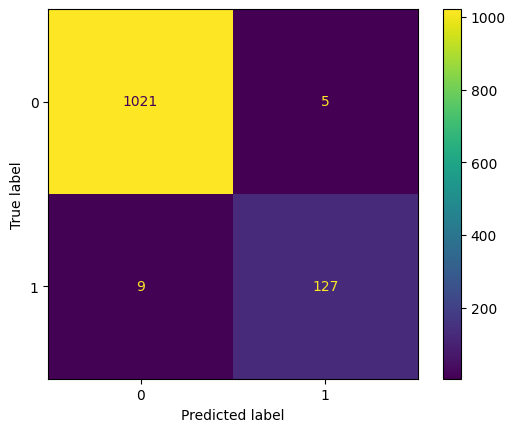

In [9]:
cm = confusion_matrix(y_test, prediction)
print(cm)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.show()